<a href="https://colab.research.google.com/github/suyogy1-bot/Matplotlib_Seaborn/blob/main/EDA_Gapminder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA Project: Gapminder World Development Dataset 🌍

**Dataset:** The famous **Gapminder** dataset — real-world data on
**population, life expectancy, and GDP per capita** for 142 countries,
tracked every 5 years from 1952 to 2007.

> This is **not** a built-in Seaborn dataset — it is downloaded fresh from a public
> GitHub CSV file (maintained by Plotly), just like downloading a dataset from Kaggle.

**Libraries used:** NumPy, Pandas, Matplotlib, Seaborn

### Roadmap
1. Import libraries
2. Download & load the dataset
3. Basic exploration
4. Missing values check
5. Filter to the latest year (2007) for country-level comparison
6. Univariate analysis — numeric (Histogram + KDE)
7. Univariate analysis — categorical (Count plot)
8. Bivariate analysis — Scatter plot
9. Bivariate analysis — Joint plot
10. Categorical vs Numeric — Bar plot, Box plot, Violin plot
11. Multivariate — Pair plot
12. Correlation heatmap
13. Trend over time — Line plot
14. Conclusions & Exercises


## Step 1: Import Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Download & Load the Dataset

We download the CSV directly from a public GitHub link using `pandas.read_csv()`.

**Columns:**
- `country` : Country name
- `year` : Year of record (every 5 years, 1952–2007)
- `pop` : Population
- `continent` : Continent
- `lifeExp` : Life expectancy (years)
- `gdpPercap` : GDP per capita ($)


In [26]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df = pd.read_csv(url)

In [27]:
df.head()

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


## Step 3: Basic Exploration

In [28]:
#1. Top 5 rows
df.head()

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


In [29]:
#2. Information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB


In [30]:
#3. What Columns we have?
df.columns.tolist()

['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap']

## Step 4: Missing Values Check

In [31]:
df.isnull().sum()

,0
country,0
year,0
pop,0
continent,0
lifeExp,0
gdpPercap,0


In [32]:
# Check duplicates

df.duplicated().sum()

np.int64(0)

## Step 5: Filter to the Latest Year (2007)

The full dataset has **multiple rows per country** (one for each year).
For most of our plots, we want **one row per country**, so we filter to the most recent year: 2007.
This gives us a clean snapshot of the world in 2007 (142 countries).


In [33]:
df[df['year'] == 2007]

,country,year,pop,continent,lifeExp,gdpPercap
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
1667,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
1679,"Yemen, Rep.",2007,22211743.0,Asia,62.698,2280.769906
1691,Zambia,2007,11746035.0,Africa,42.384,1271.211593


In [34]:
df_2007 = df[df['year'] == 2007].reset_index(drop=True)

In [35]:
df_2007

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
1,Albania,2007,3600523.0,Europe,76.423,5937.029526
2,Algeria,2007,33333216.0,Africa,72.301,6223.367465
3,Angola,2007,12420476.0,Africa,42.731,4797.231267
4,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
137,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
138,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
139,"Yemen, Rep.",2007,22211743.0,Asia,62.698,2280.769906
140,Zambia,2007,11746035.0,Africa,42.384,1271.211593


## Step 6: Univariate Analysis — Numeric Columns

### Histogram + KDE


In [36]:
a = df.corr(numeric_only=True)
a

,year,pop,lifeExp,gdpPercap
year,1.000000,0.082308,0.435611,0.227318
pop,0.082308,1.000000,0.064955,-0.025600
lifeExp,0.435611,0.064955,1.000000,0.583706
gdpPercap,0.227318,-0.025600,0.583706,1.000000


<Axes: xlabel='lifeExp', ylabel='Density'>

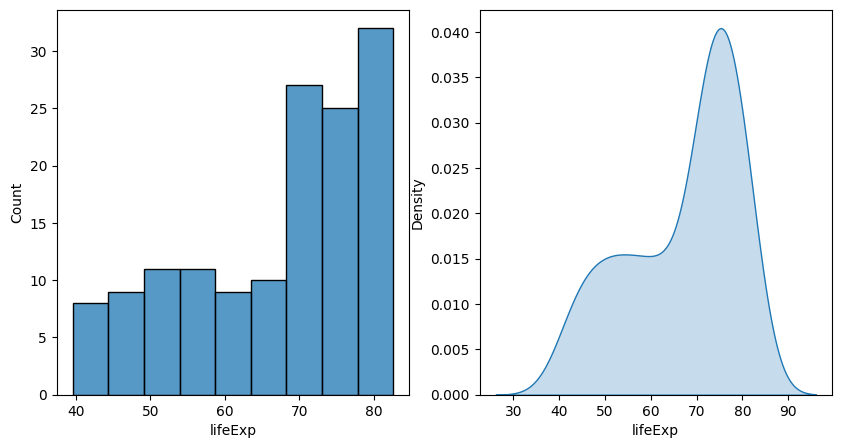

In [41]:
a, b = plt.subplots(1,2, figsize=(10, 5))

sns.histplot(data=df_2007, x="lifeExp", ax=b[0])
sns.kdeplot(data=df_2007, x="lifeExp", ax=b[1], fill=True)

## Step 7: Univariate Analysis — Categorical Column

### Count Plot
How many countries do we have per continent?


<Axes: xlabel='continent', ylabel='count'>

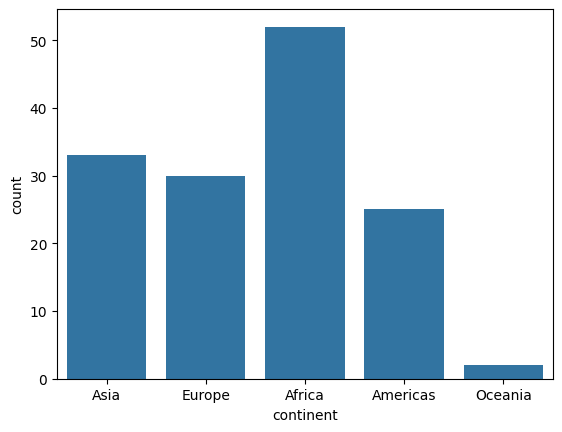

In [42]:
sns.countplot(data=df_2007, x="continent")

## Step 8: Bivariate Analysis — Scatter Plot

Does a richer country (higher GDP per capita) also have higher life expectancy?


## Step 9: Joint Plot

A joint plot combines a scatter/KDE plot with the individual distributions of both variables.


## Step 10: Categorical vs Numeric — Bar, Box & Violin Plots


**point:**
- **Bar plot** = average value per category.
- **Box plot** = spread, median, and outliers.
- **Violin plot** = full distribution shape per category.


## Step 11: Multivariate Analysis — Pair Plot


## Step 12: Correlation Heatmap

## Step 13: Trend Over Time — Line Plot

Now let's use the **full dataset** (all years) to see how life expectancy changed
over time for a few selected countries.


## Step 14: Conclusions & Class Exercises

### Key Findings
1. **GDP per capita and life expectancy** are positively related — richer countries tend to have longer life expectancy, though the relationship flattens out at higher GDP.
2. **Africa** has the lowest average life expectancy among continents in 2007, while **Oceania/Europe** are the highest.
3. Life expectancy has **increased for almost all countries** between 1952 and 2007.
4. Population size (bubble size in the scatter plot) does not show a strong direct relationship with life expectancy.

### Exercises for Students
1. Filter the dataset to year `1952` and repeat the scatter plot — how different does the world look?
2. Make a **violin plot** of `gdpPercap` by continent (use `plt.yscale("log")`).
3. Use `groupby("continent")["lifeExp"].mean()` to find which continent improved the most from 1952 to 2007.
4. Create a **jointplot** of `gdpPercap` vs `pop` with `kind="hex"`.
5. Pick your own 5 countries and redraw the line plot from Step 13.


In [43]:
# 1. Import all the libraries
# 2. Load your dataset
# 3. Explore the data -> head, info, columns, shape
# 4. Check for missing values and duplicate values
# 5. Univariate Analysis -> When are we are plotting/analysis on one column only.
# 6. Bivariate Analysis -> When are we are plotting/Analyis on two columns.
# 7. Multivariate Analysis -> When are we are plotting/analysis on multiple columns.
# 8. Correlation Heatmap
# 9. Trend Over Time
# 10.Key Findings
